In [1]:
# Importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Text Processing
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, FreqDist, ngrams
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
import hdbscan
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.neighbors import NearestNeighbors

# Visualization
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from collections import Counter
import folium
from folium.plugins import MarkerCluster

import warnings
warnings.filterwarnings('ignore')

### Data Loading

In [2]:
df = pd.read_json("yelp_academic_dataset_business.json", lines = True)

In [3]:
print(f"Shape of the dataset: {df.shape}")

Shape of the dataset: (150346, 14)


In [4]:
df.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [5]:
df.dtypes

business_id      object
name             object
address          object
city             object
state            object
postal_code      object
latitude        float64
longitude       float64
stars           float64
review_count      int64
is_open           int64
attributes       object
categories       object
hours            object
dtype: object

### Data Cleaning

In [6]:
# Checking missing values
df.isnull().sum()

business_id         0
name                0
address             0
city                0
state               0
postal_code         0
latitude            0
longitude           0
stars               0
review_count        0
is_open             0
attributes      13744
categories        103
hours           23223
dtype: int64

* The essential columns required for the project: business_id, name, address, city, state, postal_code, latitude, longitude, stars, review_count, and is_open have 0 missing values.
* Other columns (attributes, categories, hours) that are not needed for analyis in this project have missing values.

Outliers before cleaning: 


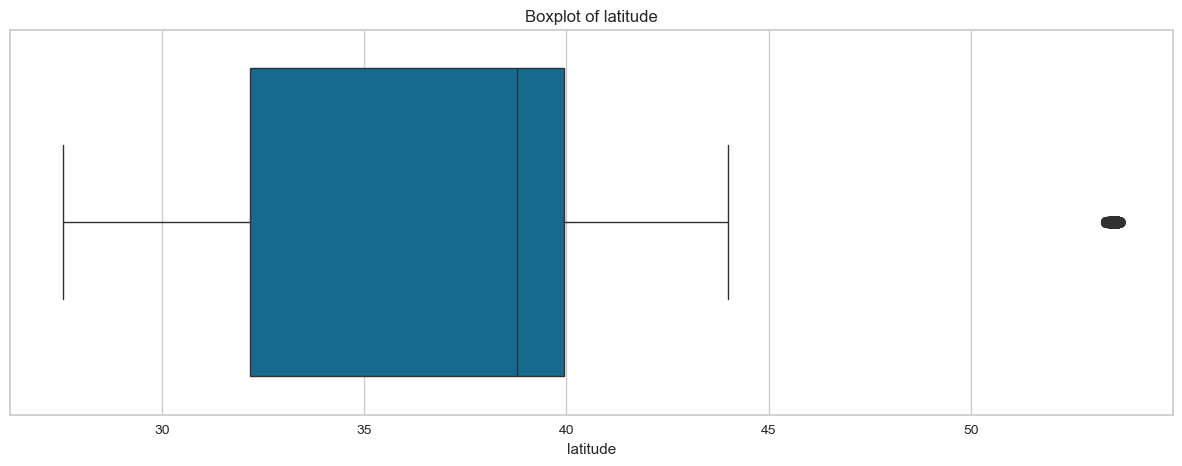

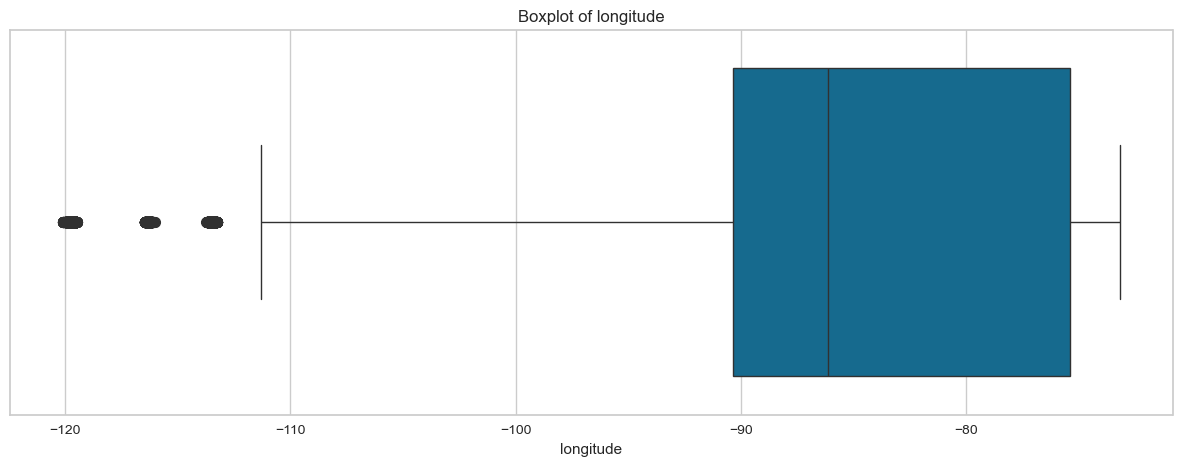

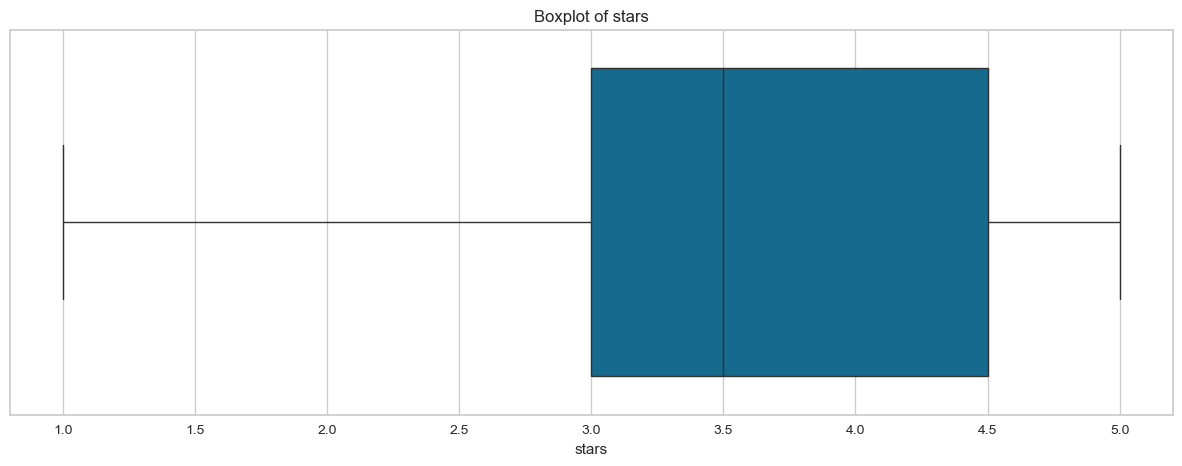

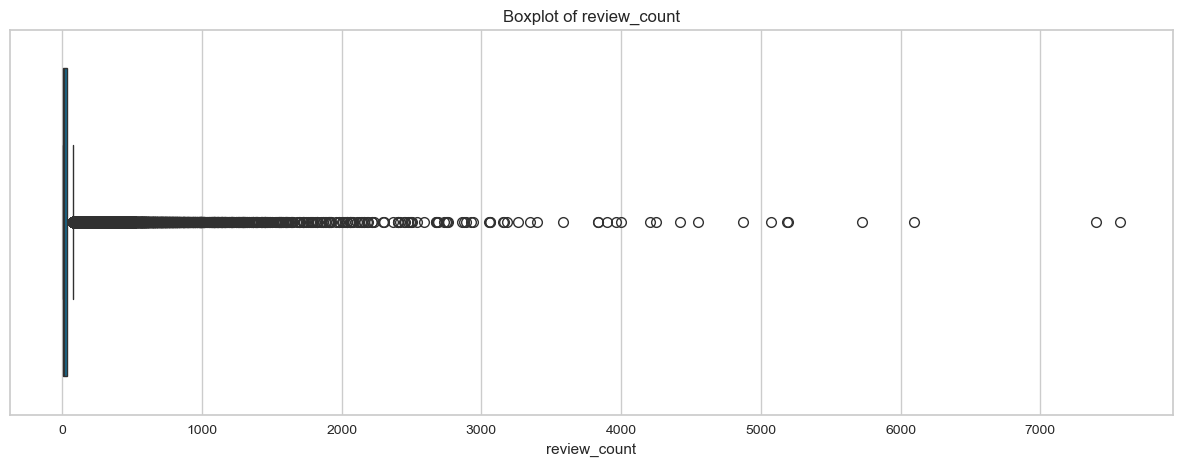

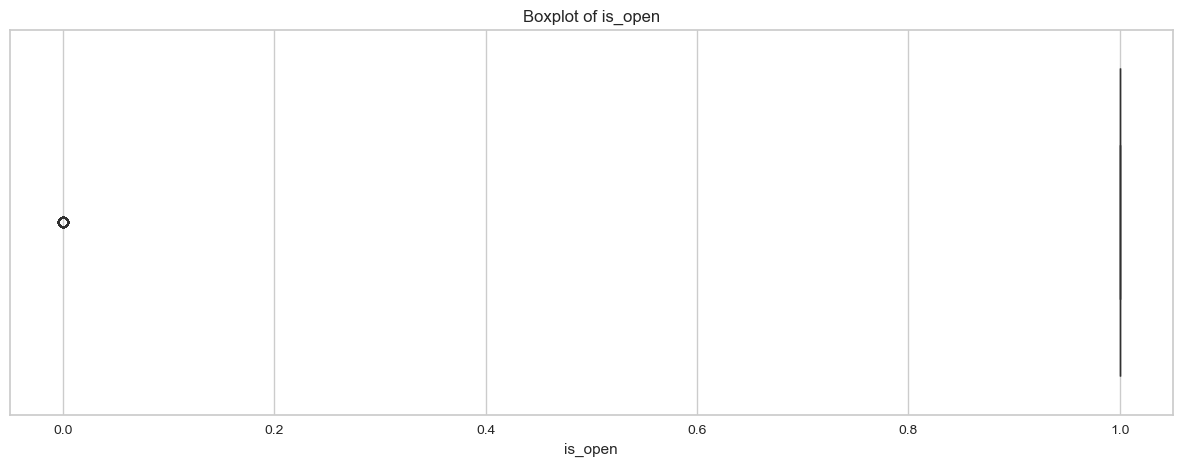

In [7]:
# Checking outliers for numerical columns (Before Cleaning)

print("Outliers before cleaning: ")

numerical_cols = ['latitude', 'longitude', 'stars', 'review_count', 'is_open']

for col in numerical_cols:
    plt.figure(figsize = (15,5))  # Creates a new window for each plot
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

* All the numerical columns do not have major outliers and look okay . 

In [8]:
df.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours'],
      dtype='object')

In [9]:
df['name'].value_counts()

name
Starbucks                  724
McDonald's                 703
Dunkin'                    510
Subway                     459
Taco Bell                  365
                          ... 
San Roque Florist            1
Perfect Taste Grill          1
il Fustino                   1
Chong's Oriental Market      1
Sic Ink                      1
Name: count, Length: 114117, dtype: int64

In [10]:
df['address'].value_counts()

address
                           5127
160 N Gulph Rd               86
51 N 12th St                 55
1 Terminal Dr                52
4100 George J Bean Pkwy      46
                           ... 
20545 County Line Rd          1
4425 Concord Pike             1
8860 Pendleton Pike           1
9608 76 Avenue NW             1
238 Apollo Beach Blvd         1
Name: count, Length: 122844, dtype: int64

In [11]:
df['city'].value_counts()

city
Philadelphia      14569
Tucson             9250
Tampa              9050
Indianapolis       7540
Nashville          6971
                  ...  
Gentilly              1
pennsauken            1
Hamiltion             1
Newtown square        1
Apollo beach          1
Name: count, Length: 1416, dtype: int64

In [12]:
df['state'].value_counts()

state
PA     34039
FL     26330
TN     12056
IN     11247
MO     10913
LA      9924
AZ      9912
NJ      8536
NV      7715
AB      5573
CA      5203
ID      4467
DE      2265
IL      2145
TX         4
CO         3
WA         2
HI         2
MA         2
NC         1
UT         1
MT         1
MI         1
SD         1
XMS        1
VI         1
VT         1
Name: count, dtype: int64

In [13]:
df['postal_code'].value_counts()

postal_code
93101      1866
89502      1804
70130      1512
19103      1362
19107      1353
           ... 
46211         1
T5K 1C4       1
T6G 0W8       1
T5H 0R8       1
T5J 4X6       1
Name: count, Length: 3362, dtype: int64

* Columns other than the numerical ones also look fine as of now. If outliers are seen later, they would be dealt with then. 

In [14]:
df.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours'],
      dtype='object')

### Exploratory Data Analysis (EDA)

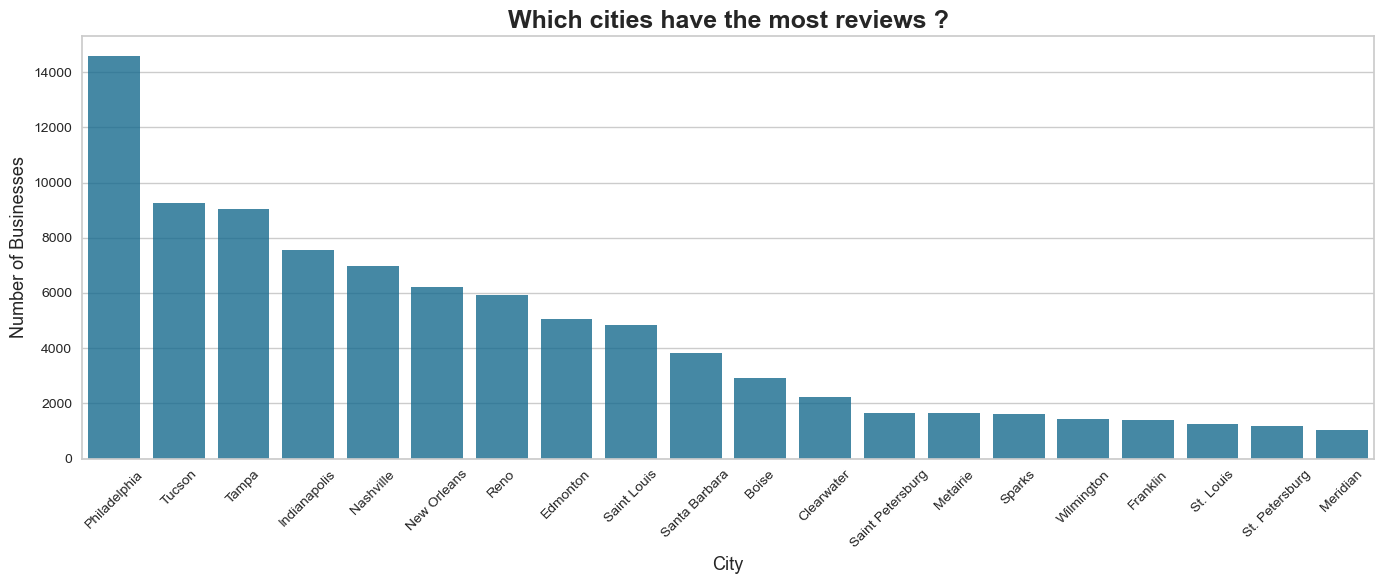

In [15]:
# Top Cities/Cities with the most reviews

x = df['city'].value_counts()
x = x.sort_values(ascending = False)
x = x.iloc[0:20]
plt.figure(figsize = (14, 6))
sns.barplot(x = x.index, y = x.values, alpha = 0.8)
plt.title("Which cities have the most reviews ?", fontweight = 'bold', fontsize = 18)
locs, labels = plt.xticks()
plt.setp(labels, rotation=45)
plt.xlabel('City', fontsize = 13)
plt.ylabel('Number of Businesses', fontsize = 13)
plt.tight_layout()
plt.show()

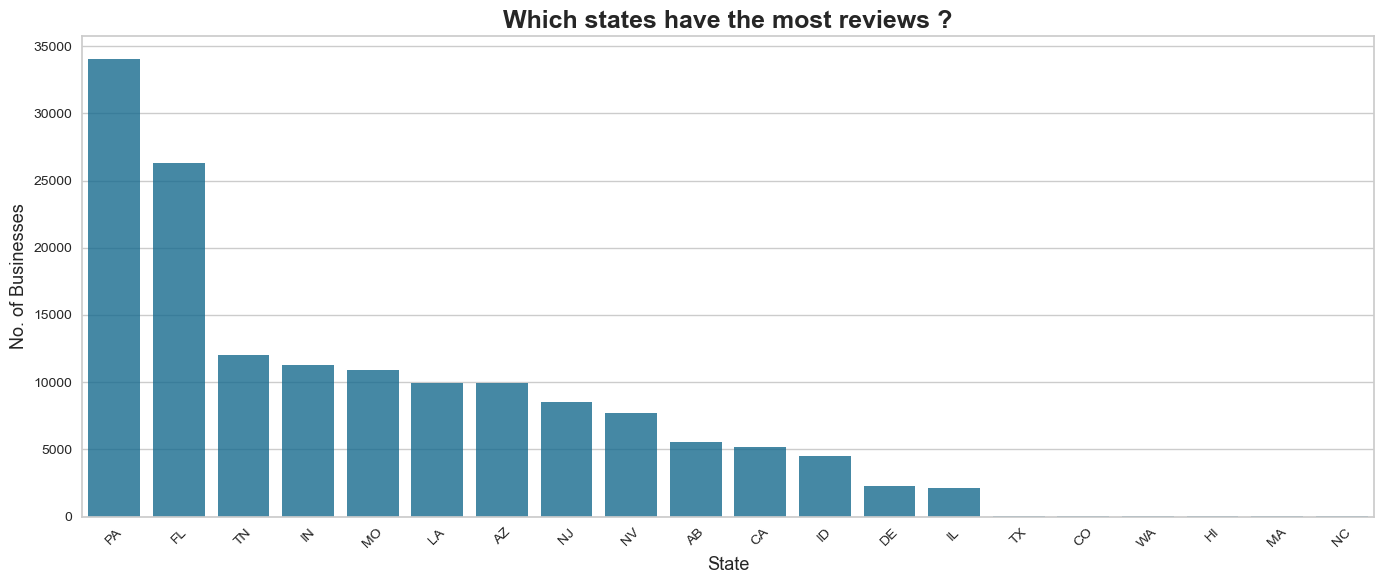

In [16]:
# Top States/States with the most reviews

x = df['state'].value_counts()
x = x.sort_values(ascending = False)
x = x.iloc[0:20]
plt.figure(figsize = (14, 6))
sns.barplot(x = x.index, y = x.values, alpha = 0.8)
plt.title("Which states have the most reviews ?", fontweight = 'bold', fontsize = 18)
locs, labels = plt.xticks()
plt.setp(labels, rotation=45)
plt.xlabel("State", fontsize = 13)
plt.ylabel("No. of Businesses", fontsize = 13)
plt.tight_layout()
plt.show()

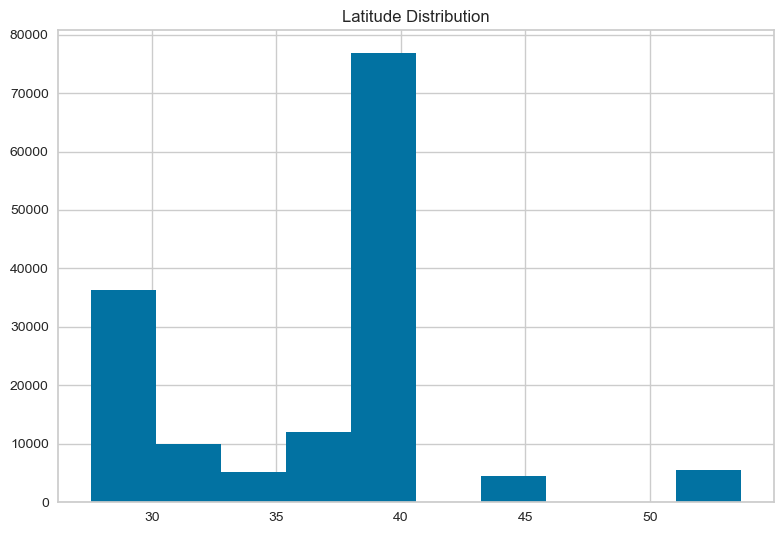

In [17]:
# Latitude Distribution

df['latitude'].hist()
plt.title("Latitude Distribution")
plt.tight_layout()
plt.show()

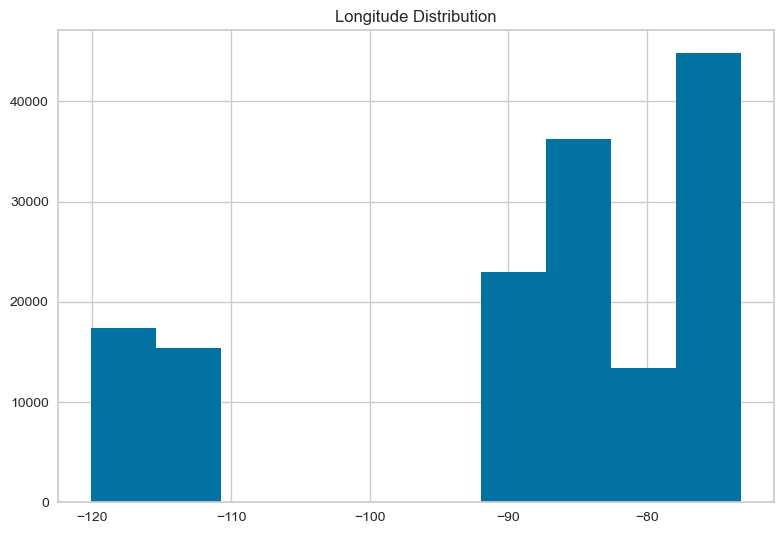

In [18]:
# Longitude Distribution

df['longitude'].hist()
plt.title("Longitude Distribution")
plt.tight_layout()
plt.show()

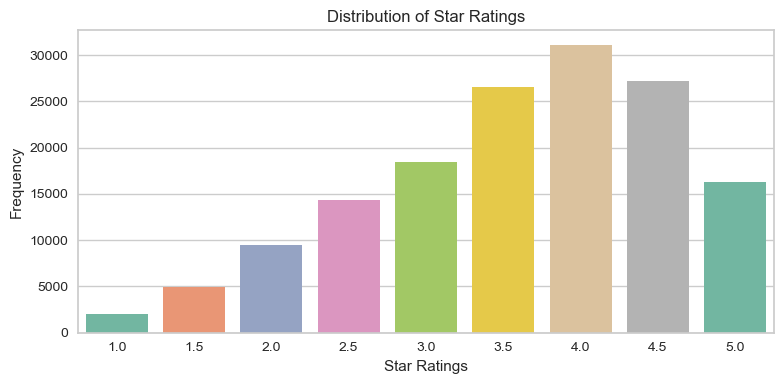

In [19]:
# Star Ratings Distribution

plt.figure(figsize = (8, 4))
sns.countplot(x = df['stars'], palette = 'Set2')
plt.title("Distribution of Star Ratings")
plt.xlabel("Star Ratings")
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

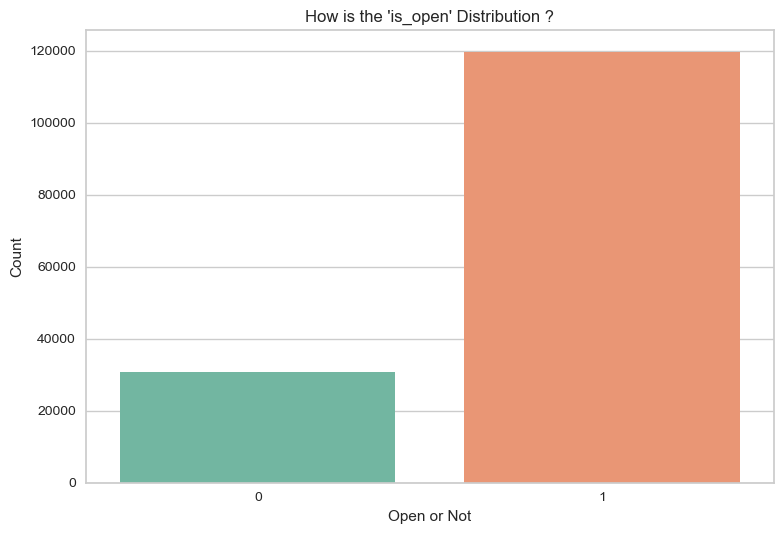

In [20]:
# 'is_open' Distribution

sns.countplot(x = df['is_open'], palette = 'Set2')
plt.title("How is the 'is_open' Distribution ?")
plt.xlabel("Open or Not")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

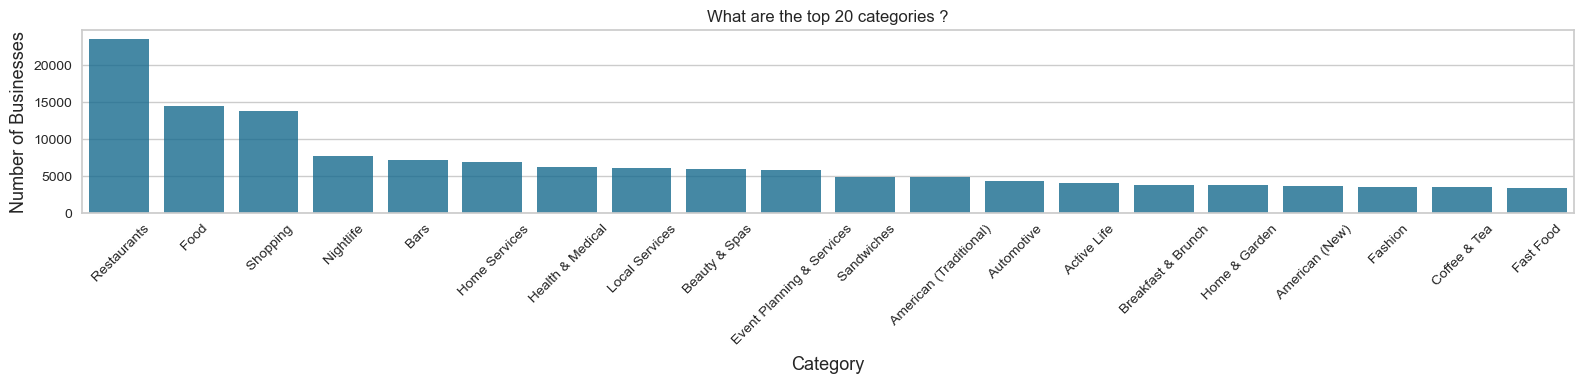

What are the top 20 categories ?
categories
Restaurants                  23549
Food                         14533
Shopping                     13851
Nightlife                     7705
Bars                          7200
Home Services                 6965
Health & Medical              6203
Local Services                6052
Beauty & Spas                 5988
Event Planning & Services     5864
Sandwiches                    4881
American (Traditional)        4864
Automotive                    4339
Active Life                   4082
Breakfast & Brunch            3796
Home & Garden                 3773
American (New)                3689
Fashion                       3575
Coffee & Tea                  3483
Fast Food                     3361
Name: count, dtype: int64


In [21]:
# Categories
cats = ''.join(df['categories'].astype('str'))
cats = pd.DataFrame(cats.split(','), columns = ['categories'])
x = cats.categories.value_counts()
x = x.sort_values(ascending = False)
x = x.iloc[0:20]

plt.figure(figsize = (16, 4))
sns.barplot(x = x.index, y = x.values, alpha = 0.8)
plt.title("What are the top 20 categories ?")
locs, labels = plt.xticks()
plt.setp(labels, rotation=45)
plt.xlabel('Category', fontsize = 13)
plt.ylabel('Number of Businesses', fontsize = 13)
plt.tight_layout()
plt.show()

print("What are the top 20 categories ?")
print(x)

### Feature Engineering

In [22]:
# Parsing Attributes

def parse_attributes(attr):
    if attr is None:
        return {}
    out = {}
    for k, v in attr.items():
        try:
            parsed = ast.literal_eval(v) if isinstance(v, str) and (v.startswith("{") or v.startswith("u") or v.startswith("'") or v.startswith('"')) else v
        except:
            parsed = v
        out[k] = parsed
    return out
df['parsed_attributes'] = df['attributes'].apply(parse_attributes)
df.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours,parsed_attributes
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None,{'ByAppointmentOnly': 'True'}
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ...",{'BusinessAcceptsCreditCards': 'True'}
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ...","{'BikeParking': 'True', 'BusinessAcceptsCredit..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...","{'RestaurantsDelivery': 'False', 'OutdoorSeati..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2...","{'BusinessAcceptsCreditCards': 'True', 'Wheelc..."


In [23]:
# Looking at an example to see the results of previous function. 

print("\n Before parsing: ")
display(df['attributes'][2])

print("\n After parsing: ")
display(df['parsed_attributes'][2])


 Before parsing: 


{'BikeParking': 'True',
 'BusinessAcceptsCreditCards': 'True',
 'RestaurantsPriceRange2': '2',
 'CoatCheck': 'False',
 'RestaurantsTakeOut': 'False',
 'RestaurantsDelivery': 'False',
 'Caters': 'False',
 'WiFi': "u'no'",
 'BusinessParking': "{'garage': False, 'street': False, 'validated': False, 'lot': True, 'valet': False}",
 'WheelchairAccessible': 'True',
 'HappyHour': 'False',
 'OutdoorSeating': 'False',
 'HasTV': 'False',
 'RestaurantsReservations': 'False',
 'DogsAllowed': 'False',
 'ByAppointmentOnly': 'False'}


 After parsing: 


{'BikeParking': 'True',
 'BusinessAcceptsCreditCards': 'True',
 'RestaurantsPriceRange2': '2',
 'CoatCheck': 'False',
 'RestaurantsTakeOut': 'False',
 'RestaurantsDelivery': 'False',
 'Caters': 'False',
 'WiFi': 'no',
 'BusinessParking': {'garage': False,
  'street': False,
  'validated': False,
  'lot': True,
  'valet': False},
 'WheelchairAccessible': 'True',
 'HappyHour': 'False',
 'OutdoorSeating': 'False',
 'HasTV': 'False',
 'RestaurantsReservations': 'False',
 'DogsAllowed': 'False',
 'ByAppointmentOnly': 'False'}

In [24]:
# Flattening attributes

attr_df = pd.json_normalize(df['parsed_attributes'])
display(attr_df)

df = pd.concat([df, attr_df], axis = 1)
df.head()

,ByAppointmentOnly,BusinessAcceptsCreditCards,BikeParking,RestaurantsPriceRange2,CoatCheck,RestaurantsTakeOut,RestaurantsDelivery,Caters,WiFi,WheelchairAccessible,...,HairSpecializesIn,Music,DietaryRestrictions.dairy-free,DietaryRestrictions.gluten-free,DietaryRestrictions.vegan,DietaryRestrictions.kosher,DietaryRestrictions.halal,DietaryRestrictions.soy-free,DietaryRestrictions.vegetarian,DietaryRestrictions
0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,False,True,True,2,False,False,False,False,no,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,False,False,True,1,NaN,True,False,True,free,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,True,True,NaN,NaN,True,NaN,False,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150341,False,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150342,NaN,True,True,2,NaN,NaN,NaN,NaN,no,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150343,NaN,True,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150344,NaN,True,True,4,NaN,None,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,HairSpecializesIn,Music,DietaryRestrictions.dairy-free,DietaryRestrictions.gluten-free,DietaryRestrictions.vegan,DietaryRestrictions.kosher,DietaryRestrictions.halal,DietaryRestrictions.soy-free,DietaryRestrictions.vegetarian,DietaryRestrictions
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
# Dropping attributes and parsed_attributes columns

df.drop(columns = ['attributes', 'parsed_attributes'], inplace = True)
df.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,HairSpecializesIn,Music,DietaryRestrictions.dairy-free,DietaryRestrictions.gluten-free,DietaryRestrictions.vegan,DietaryRestrictions.kosher,DietaryRestrictions.halal,DietaryRestrictions.soy-free,DietaryRestrictions.vegetarian,DietaryRestrictions
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# Multi-Hot Encoding Categories columns

df['categories_list'] = df.categories.fillna("").apply(lambda x: [c.strip() for c in x.split(",")])
display(df['categories_list'])

mlb = MultiLabelBinarizer()
cat_features = pd.DataFrame(mlb.fit_transform(df['categories_list']), columns = mlb.classes_, index = df.index)
display(cat_features)

0         [Doctors, Traditional Chinese Medicine, Naturo...
1         [Shipping Centers, Local Services, Notaries, M...
2         [Department Stores, Shopping, Fashion, Home & ...
3         [Restaurants, Food, Bubble Tea, Coffee & Tea, ...
4                               [Brewpubs, Breweries, Food]
                                ...                        
150341                         [Nail Salons, Beauty & Spas]
150342    [Pets, Nurseries & Gardening, Pet Stores, Hobb...
150343    [Shopping, Jewelry, Piercing, Toy Stores, Beau...
150344    [Fitness/Exercise Equipment, Eyewear & Opticia...
150345    [Beauty & Spas, Permanent Makeup, Piercing, Ta...
Name: categories_list, Length: 150346, dtype: object

,,& Probates,3D Printing,ATV Rentals/Tours,Acai Bowls,Accessories,Accountants,Acne Treatment,Active Life,Acupuncture,...,Wine Tasting Room,Wine Tours,Wineries,Women's Clothing,Workers Compensation Law,Wraps,Yelp Events,Yoga,Ziplining,Zoos
0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150341,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
150342,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
150343,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
150344,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
# Scaling numerical features

num_features = df[['latitude', 'longitude', 'stars', 'review_count']].copy()
X = pd.concat([num_features, cat_features], axis = 1).fillna(0)
print("\n Before Scaling: ")
display(X)

# Scaling through StandardScaler()
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[['latitude', 'longitude', 'stars', 'review_count']] = scaler.fit_transform(
    X[['latitude', 'longitude', 'stars', 'review_count']]
)
print("\n After Scaling: ")
display(X_scaled)


 Before Scaling: 


,latitude,longitude,stars,review_count,,& Probates,3D Printing,ATV Rentals/Tours,Acai Bowls,Accessories,...,Wine Tasting Room,Wine Tours,Wineries,Women's Clothing,Workers Compensation Law,Wraps,Yelp Events,Yoga,Ziplining,Zoos
0,34.426679,-119.711197,5.0,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,38.551126,-90.335695,3.0,15,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,32.223236,-110.880452,3.5,22,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,39.955505,-75.155564,4.0,80,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,40.338183,-75.471659,4.5,13,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150341,53.468419,-113.492054,3.0,13,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
150342,36.115118,-86.766925,4.0,5,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
150343,39.908707,-86.065088,3.5,8,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
150344,38.782351,-89.950558,4.0,24,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



 After Scaling: 


,latitude,longitude,stars,review_count,,& Probates,3D Printing,ATV Rentals/Tours,Acai Bowls,Accessories,...,Wine Tasting Room,Wine Tours,Wineries,Women's Clothing,Workers Compensation Law,Wraps,Yelp Events,Yoga,Ziplining,Zoos
0,-0.382185,-2.034652,1.440118,-0.312637,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.320119,-0.065580,-0.612390,-0.246587,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,-0.757383,-1.442718,-0.099263,-0.188793,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0.559254,0.951960,0.413864,0.290072,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0.624416,0.930772,0.926991,-0.263100,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150341,2.860210,-1.617776,-0.612390,-0.263100,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
150342,-0.094680,0.173638,0.413864,-0.329150,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
150343,0.551286,0.220683,-0.099263,-0.304381,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
150344,0.359492,-0.039764,0.413864,-0.172280,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### K-Means Clustering

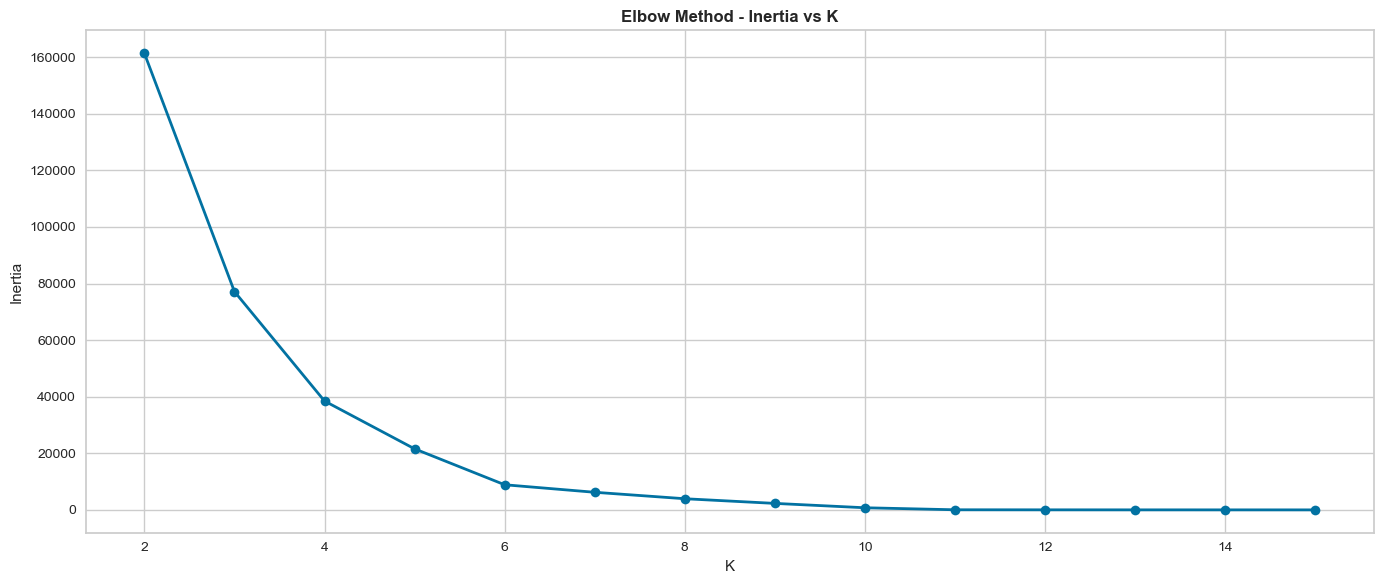

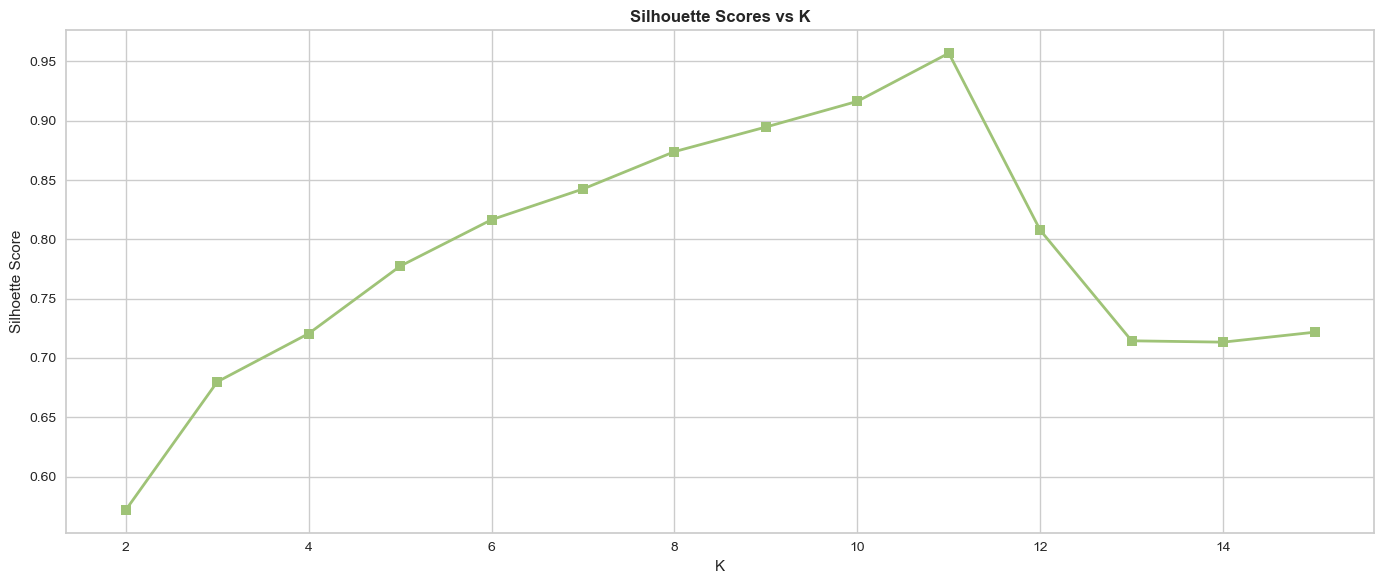

The best k by Silhoette Score is 11


In [28]:
# Extracting geographical features (latitude & longitude)
geo_features = X_scaled[['latitude', 'longitude']]

# Elbow Method
inertias, sil_scores = [], []
k_range = range(2, 16)

for k in k_range:
    km = KMeans(n_clusters = k, init = 'k-means++', n_init = 10, random_state = 42)
    labels = km.fit_predict(geo_features)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(geo_features, labels, sample_size = 10_000))

plt.figure(figsize = (14, 6))
plt.plot(list(k_range), inertias, 'bo-', linewidth = 2)
plt.title("Elbow Method - Inertia vs K", fontweight = 'bold')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()


plt.figure(figsize = (14, 6))
plt.plot(list(k_range), sil_scores, 'gs-', linewidth = 2)
plt.title("Silhouette Scores vs K", fontweight = 'bold')
plt.xlabel("K")
plt.ylabel("Silhoette Score")
plt.tight_layout()
plt.show()

best_k = sil_scores.index(max(sil_scores)) + 2
print(f"The best k by Silhoette Score is {best_k}")

In [29]:
# Fitting the final K-Means model 

kmeans = KMeans(n_clusters = best_k, 
                init = 'k-means++', 
                n_init = 15, 
                max_iter = 300,
                random_state = 42)

df['cluster_kmeans'] = kmeans.fit_predict(geo_features)

print("Number of K-Means clusters: ", df['cluster_kmeans'].nunique())
print(df['cluster_kmeans'].value_counts().sort_index())

Number of K-Means clusters:  11
cluster_kmeans
0     44847
1      4471
2      9925
3      9916
4     13062
5      5573
6     26336
7      7732
8     12058
9      5177
10    11249
Name: count, dtype: int64


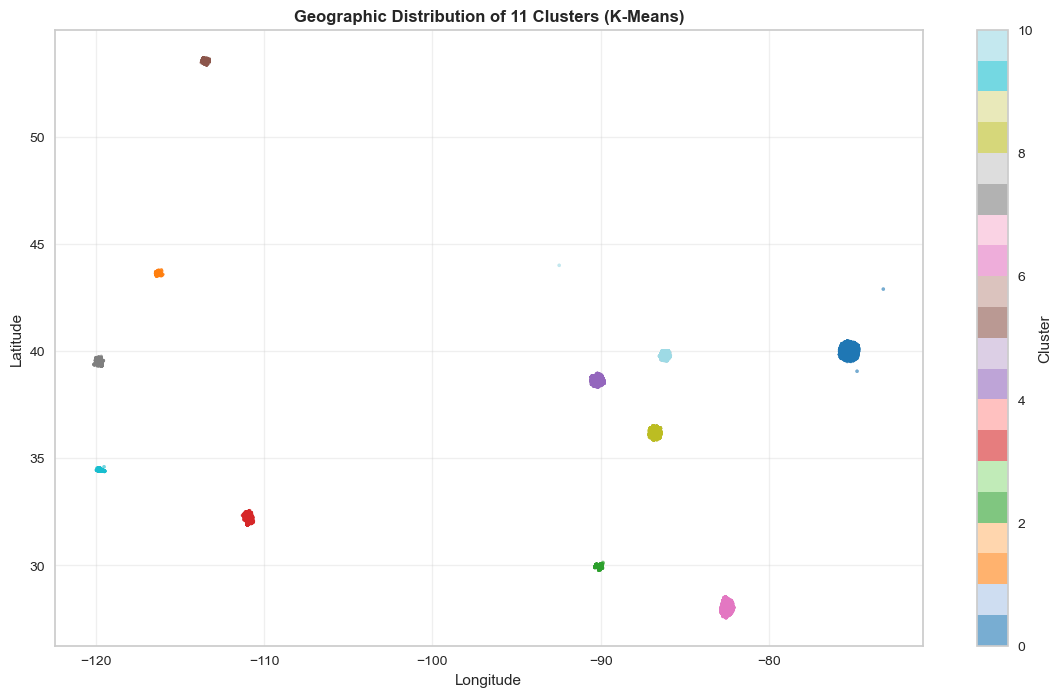

In [30]:
plt.figure(figsize=(14,8))
scatter = plt.scatter(df['longitude'], df['latitude'],
                     c=df['cluster_kmeans'], cmap='tab20',
                     s=5, alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Geographic Distribution of {best_k} Clusters (K-Means)', fontweight = 'bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
df.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count',
       ...
       'DietaryRestrictions.dairy-free', 'DietaryRestrictions.gluten-free',
       'DietaryRestrictions.vegan', 'DietaryRestrictions.kosher',
       'DietaryRestrictions.halal', 'DietaryRestrictions.soy-free',
       'DietaryRestrictions.vegetarian', 'DietaryRestrictions',
       'categories_list', 'cluster_kmeans'],
      dtype='object', length=103)

In [32]:
# K-Means Cluster Summary

cluster_summary = df.groupby('cluster_kmeans').agg({
    'business_id': 'count',
    'stars': 'mean',
    'review_count': 'mean',
    'city': lambda x: x.value_counts().index[0]
}).round(0)

cluster_summary.columns = ['# Businesses', 'Avg Star Rating', 'Avg Reviews', 'Primary City']
cluster_summary = cluster_summary.sort_values('# Businesses', ascending = False)
print(cluster_summary)

                # Businesses  Avg Star Rating  Avg Reviews   Primary City
cluster_kmeans                                                           
0                      44847              4.0         41.0   Philadelphia
6                      26336              4.0         43.0          Tampa
4                      13062              4.0         41.0    Saint Louis
8                      12058              4.0         50.0      Nashville
10                     11249              4.0         42.0   Indianapolis
2                       9925              4.0         75.0    New Orleans
3                       9916              4.0         42.0         Tucson
7                       7732              4.0         53.0           Reno
5                       5573              3.0         19.0       Edmonton
9                       5177              4.0         66.0  Santa Barbara
1                       4471              4.0         34.0          Boise


### DBSCAN Clustering

In [33]:
# Coverting the coordinates to radians
coords = np.radians(X_scaled[['latitude', 'longitude']].values)

# eps = distance in radians (5 km = 5 / 6371)
eps_km = 5
eps = eps_km / 6371.0

# DBSCAN
db = DBSCAN(
    eps = eps,
    min_samples = 50,
    metric = 'haversine'
)

df['cluster_db'] = db.fit_predict(coords)

print("Number of DBSCAN clusters: ", df['cluster_db'].nunique())
print(df['cluster_db'].value_counts().sort_index())

Number of DBSCAN clusters:  12
cluster_db
-1         3
 0      5177
 1     13062
 2      9916
 3     44845
 4     12058
 5     26336
 6     11248
 7      9925
 8      5573
 9      7732
 10     4471
Name: count, dtype: int64


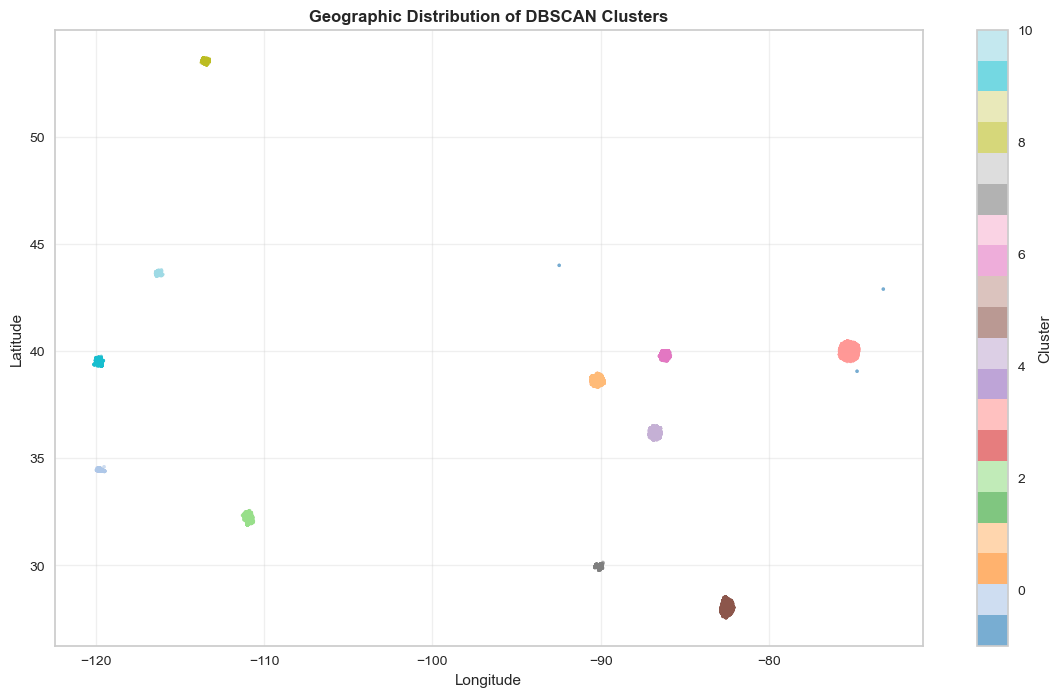

In [34]:
plt.figure(figsize=(14,8))
scatter = plt.scatter(df['longitude'], df['latitude'],
                     c=df['cluster_db'], cmap='tab20',
                     s=5, alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Geographic Distribution of DBSCAN Clusters', fontweight = 'bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.show()

In [35]:
# DBSCAN Cluster Summary

cluster_summary = df.groupby('cluster_db').agg({
    'business_id': 'count',
    'stars': 'mean',
    'review_count': 'mean',
    'city': lambda x: x.value_counts().index[0]
}).round(0)

cluster_summary.columns = ['# Businesses', 'Avg Star Rating', 'Avg Reviews', 'Primary City']
cluster_summary = cluster_summary.sort_values('# Businesses', ascending = False)
print(cluster_summary)

            # Businesses  Avg Star Rating  Avg Reviews   Primary City
cluster_db                                                           
 3                 44845              4.0         41.0   Philadelphia
 5                 26336              4.0         43.0          Tampa
 1                 13062              4.0         41.0    Saint Louis
 4                 12058              4.0         50.0      Nashville
 6                 11248              4.0         42.0   Indianapolis
 7                  9925              4.0         75.0    New Orleans
 2                  9916              4.0         42.0         Tucson
 9                  7732              4.0         53.0           Reno
 8                  5573              3.0         19.0       Edmonton
 0                  5177              4.0         66.0  Santa Barbara
 10                 4471              4.0         34.0          Boise
-1                     3              4.0         21.0          Boise


### HDBSCAN Clustering

In [36]:
hdb = hdbscan.HDBSCAN(
    metric = 'haversine',
    min_cluster_size = 50,
    min_samples = 20
)

df['cluster_hdb'] = hdb.fit_predict(coords)

print("Number of HDBSCAN clusters: ", df['cluster_hdb'].nunique())
print(df['cluster_hdb'].value_counts().sort_index())

Number of HDBSCAN clusters:  704
cluster_hdb
-1      44962
 0        190
 1         50
 2        139
 3        298
        ...  
 698       91
 699       53
 700      135
 701       68
 702     1536
Name: count, Length: 704, dtype: int64


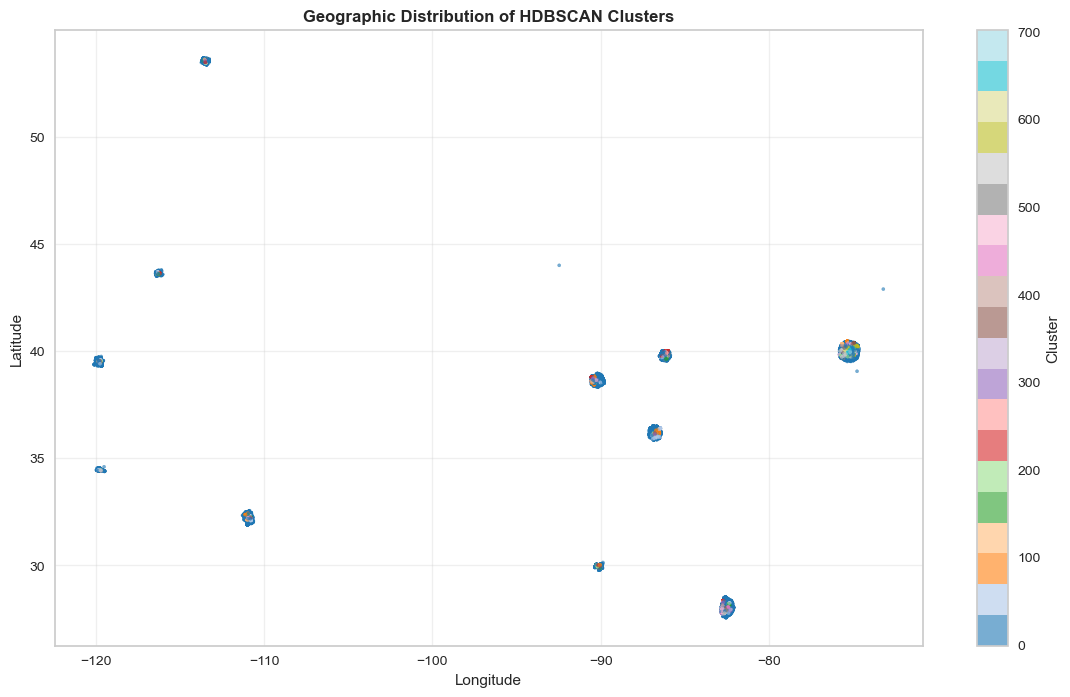

In [37]:
plt.figure(figsize=(14,8))
scatter = plt.scatter(df['longitude'], df['latitude'],
                     c=df['cluster_hdb'], cmap='tab20',
                     s=5, alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Geographic Distribution of HDBSCAN Clusters', fontweight = 'bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.show()

In [38]:
# HDBSCAN Cluster Summary

cluster_summary = df.groupby('cluster_hdb').agg({
    'business_id': 'count',
    'stars': 'mean',
    'review_count': 'mean',
    'city': lambda x: x.value_counts().index[0]
}).round(0)

cluster_summary.columns = ['# Businesses', 'Avg Star Rating', 'Avg Reviews', 'Primary City']
cluster_summary = cluster_summary.sort_values('# Businesses', ascending = False)
print(cluster_summary)

             # Businesses  Avg Star Rating  Avg Reviews    Primary City
cluster_hdb                                                            
-1                  44962              4.0         37.0    Philadelphia
 375                 2269              4.0        164.0     New Orleans
 702                 1536              4.0        111.0    Philadelphia
 371                 1162              4.0         86.0            Reno
 215                  876              4.0         42.0        Metairie
...                   ...              ...          ...             ...
 531                   50              4.0         53.0  St. Petersburg
 340                   50              4.0         36.0            Reno
 1                     50              3.0         15.0     Springfield
 328                   50              3.0         34.0        Kirkwood
 396                   50              3.0         28.0      Royersford

[704 rows x 4 columns]
